# NFL 4th Down Decision Analysis
## Coach Deep Dive

This notebook takes the model built in `03_modeling.ipynb` and applies it to answer the core question of this project: which NFL coaches make the best and worst 4th down decisions, how have they evolved over time, and what does it cost them in win probability?

---

### Setup & Data Load
Load the processed dataset, trained XGBoost model, and label encoder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")
models_path = os.path.join(project_root, "outputs", "models")

# Load data
fourth_downs = pd.read_parquet(os.path.join(processed_path, "fourth_downs.parquet"))

# Load model and encoder
with open(os.path.join(models_path, "fourth_down_model.pkl"), "rb") as f:
    model = pickle.load(f)

with open(os.path.join(models_path, "label_encoder.pkl"), "rb") as f:
    le = pickle.load(f)

print(f"Data loaded: {fourth_downs.shape}")

Data loaded: (39367, 29)


Data and model loaded successfully. We have 39,367 4th down plays and the trained model ready to generate recommendations for each one.

---

### Rebuild Full Prediction Dataset
Apply the model to every play to generate recommended decisions, predicted probabilities, and disagreement classifications.

In [3]:
features = [
    'ydstogo',
    'yardline_100',
    'score_differential',
    'game_seconds_remaining',
    'qtr',
    'goal_to_go',
    'wp'
]

X_full = fourth_downs[features].dropna()
fourth_downs_clean = fourth_downs.loc[X_full.index].copy()

fourth_downs_clean['model_decision'] = le.inverse_transform(model.predict(X_full))
proba = model.predict_proba(X_full)
fourth_downs_clean['prob_go'] = proba[:, 1]
fourth_downs_clean['prob_punt'] = proba[:, 2]
fourth_downs_clean['prob_fg'] = proba[:, 0]

fourth_downs_clean['disagreement'] = (
    fourth_downs_clean['decision'] != fourth_downs_clean['model_decision']
)

def disagreement_direction(row):
    if not row['disagreement']:
        return 'agree'
    if row['decision'] in ['punt', 'field_goal'] and row['model_decision'] == 'go':
        return 'too_conservative'
    if row['decision'] == 'go' and row['model_decision'] in ['punt', 'field_goal']:
        return 'too_aggressive'
    return 'other'

fourth_downs_clean['disagreement_type'] = fourth_downs_clean.apply(disagreement_direction, axis=1)

print(f"Ready: {fourth_downs_clean.shape}")
print(fourth_downs_clean['disagreement_type'].value_counts())

Ready: (39367, 35)
disagreement_type
agree               36708
too_aggressive       1575
too_conservative      879
other                 205
Name: count, dtype: int64


Full prediction dataset rebuilt — 39,367 plays with model recommendations, predicted probabilities, and disagreement classifications for every play.

Each play now has:
- `model_decision` — what the model recommends: `go`, `punt`, or `field_goal`
- `prob_go`, `prob_punt`, `prob_fg` — predicted probability for each option
- `disagreement` — boolean flag for whether the coach and model disagree
- `disagreement_type` — direction: `agree`, `too_aggressive`, `too_conservative`, or `other`

Results match notebook 03: 36,708 agreements, 1,575 too aggressive, 879 too conservative, 205 other.

---

### Visualization 1 — Coach Aggressiveness Over Time
How have individual coaches evolved in their 4th down aggressiveness across seasons? We track 6 coaches with long or notable tenures to identify trends and philosophy shifts.

/tmp/ipykernel_19555/2504446769.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ].groupby(['coach', 'season']).apply(


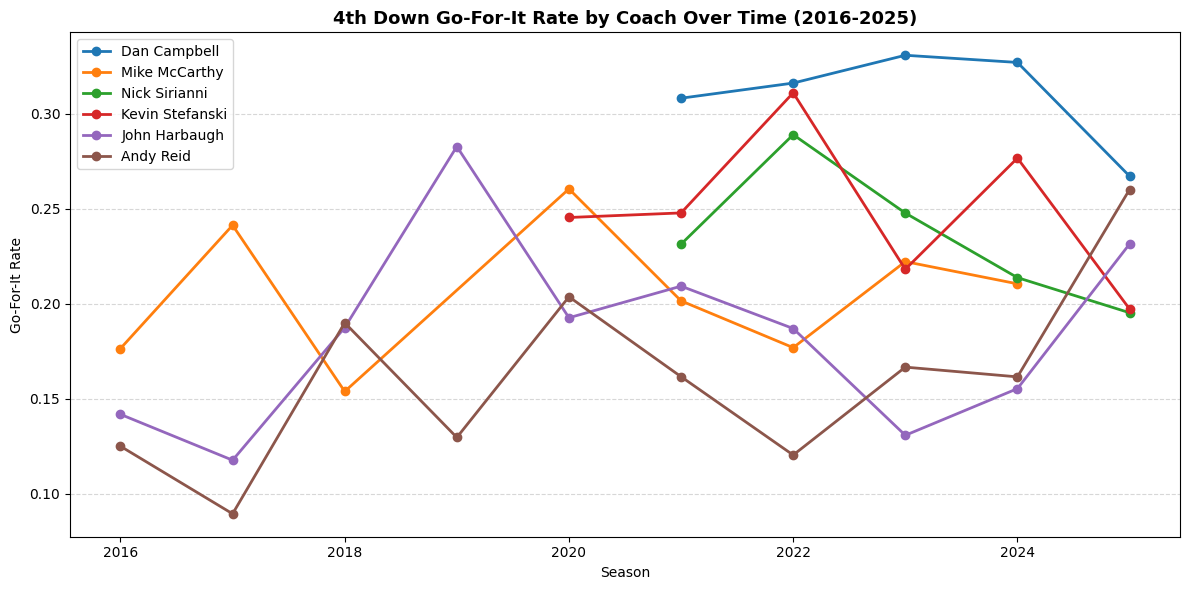

In [4]:
# Pick coaches with long tenures for interesting comparison
coaches_to_track = ['Dan Campbell', 'Mike McCarthy', 'Nick Sirianni', 
                    'Kevin Stefanski', 'John Harbaugh', 'Andy Reid']

coach_season = fourth_downs_clean[
    fourth_downs_clean['coach'].isin(coaches_to_track)
].groupby(['coach', 'season']).apply(
    lambda x: (x['decision'] == 'go').sum() / len(x)
).reset_index()
coach_season.columns = ['coach', 'season', 'go_rate']

plt.figure(figsize=(12, 6))
for coach in coaches_to_track:
    data = coach_season[coach_season['coach'] == coach]
    plt.plot(data['season'], data['go_rate'], marker='o', linewidth=2, label=coach)

plt.title('4th Down Go-For-It Rate by Coach Over Time (2016-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Go-For-It Rate')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "coach_trends_over_time.png"), dpi=150)
plt.show()

![Coach Aggressiveness Over Time](../outputs/figures/coach_trends_over_time.png)

Tracking individual coaches over time reveals that 4th down philosophy is not static — coaches evolve, adapt, and sometimes reverse course dramatically.

**Dan Campbell (blue)** — arrives in 2021 and immediately establishes himself as the most aggressive coach in the league, peaking at 33% in 2023–2024 before pulling back slightly in 2025. His aggressiveness is the most consistent of any coach on this chart.

**Kevin Stefanski (red)** — the most volatile line on the chart. Spikes to 31% in 2022, drops sharply, then climbs again to 27% in 2024 before falling back in 2025. No consistent philosophy year to year.

**Nick Sirianni (green)** — starts moderate in 2021, climbs to 29% in 2022, then becomes increasingly inconsistent. The sharp 2025 drop is notable given the Eagles' success in recent years.

**John Harbaugh (purple)** — the most erratic coach on the chart with a huge spike to 28% in 2019 followed by a crash. His aggressiveness appears situational rather than philosophical.

**Mike McCarthy (orange)** — flat and moderate throughout his entire tenure, never committing strongly to either aggressive or conservative tendencies. Consistent mediocrity.

**Andy Reid (brown)** — stays conservative for most of his career then spikes sharply to 26% in 2025, a notable late-career shift toward aggressiveness from one of the most accomplished coaches in NFL history.

---

### Visualization 2 — Win Probability Added by Coach
Which coaches actually generate positive win probability through their 4th down decisions? We measure average WPA per play for every qualified coach.

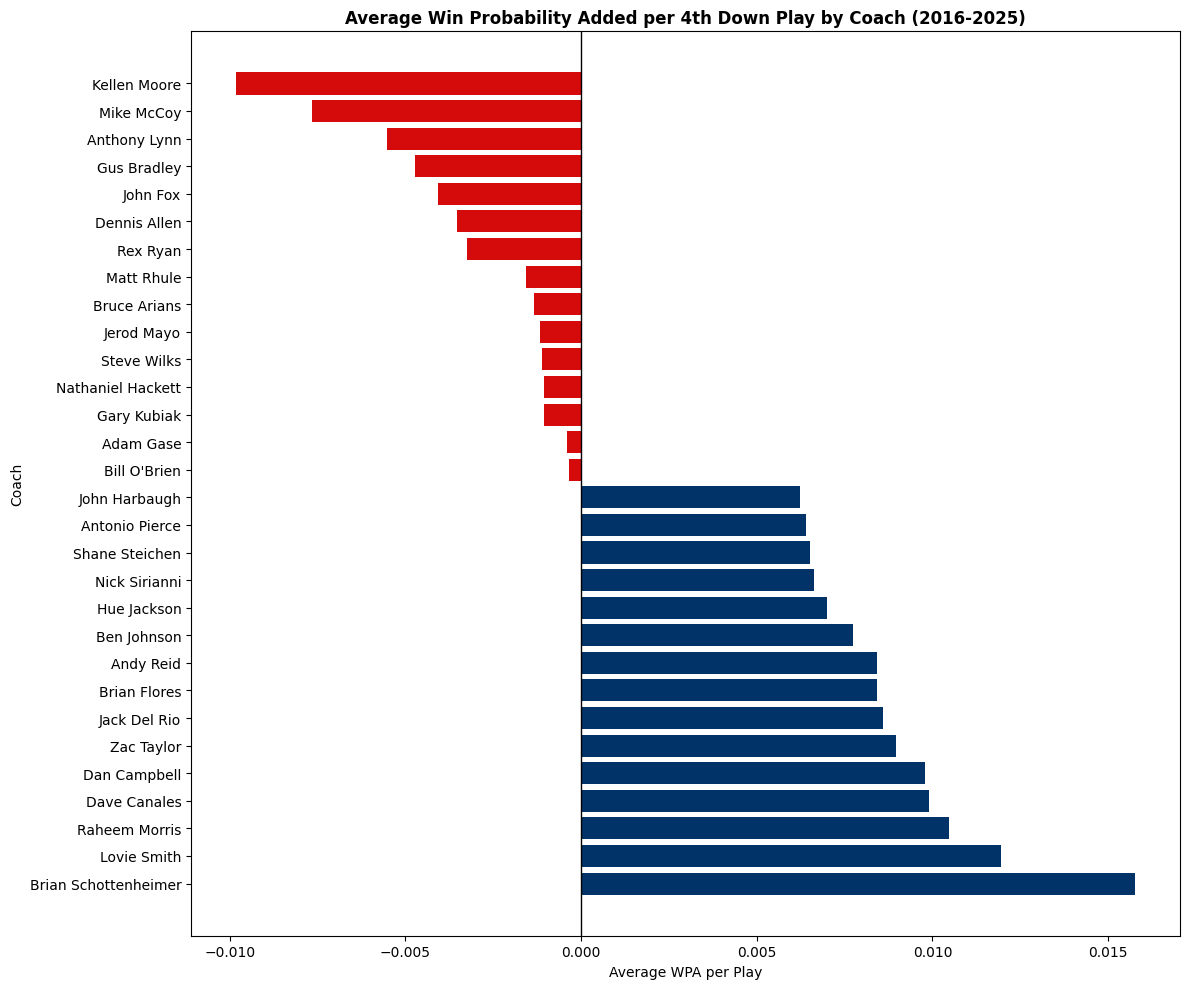

In [5]:
coach_wpa = fourth_downs_clean.groupby('coach').agg(
    total_plays=('decision', 'count'),
    total_wpa=('wpa', 'sum'),
    avg_wpa=('wpa', 'mean')
).reset_index()

coach_wpa = coach_wpa[coach_wpa['total_plays'] >= 100]
coach_wpa = coach_wpa.sort_values('avg_wpa', ascending=False)

top_bottom_wpa = pd.concat([coach_wpa.head(15), coach_wpa.tail(15)])

colors = ['#013369' if x > 0 else '#D50A0A' for x in top_bottom_wpa['avg_wpa']]

plt.figure(figsize=(12, 10))
plt.barh(top_bottom_wpa['coach'], top_bottom_wpa['avg_wpa'], color=colors)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Average Win Probability Added per 4th Down Play by Coach (2016-2025)', 
          fontsize=12, fontweight='bold')
plt.xlabel('Average WPA per Play')
plt.ylabel('Coach')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "coach_wpa.png"), dpi=150)
plt.show()

![Average WPA per 4th Down Play by Coach](../outputs/figures/coach_wpa.png)

Win probability added per play is the ultimate measure of 4th down decision quality — it captures not just what the coach decided, but whether the outcome moved the needle on winning.

**Top WPA generators (blue):**
- **Brian Schottenheimer (0.016)** — leads the league, though his sample size is small as a first-year head coach. His aggressive decisions are paying off in win probability
- **Lovie Smith (0.012)** — a surprising name at the top given his conservative reputation, suggesting his decisions were well-timed even if infrequent
- **Raheem Morris, Dave Canales, Dan Campbell** — all newer aggressive coaches generating consistent positive WPA
- **Andy Reid (0.009)** — one of the best coaches in NFL history and his 4th down WPA reflects that, consistently making the right call at the right time
- **Zac Taylor (0.009)** — quietly one of the best 4th down coaches in the league by this metric

**Worst WPA performers (red):**
- **Kellen Moore (-0.010)** — the worst on the chart and the most surprising finding. Despite being considered an analytics-friendly offensive coach, his 4th down decisions have consistently hurt his teams' win probability
- **Mike McCoy, Anthony Lynn, Gus Bradley** — all older era coaches losing WP on 4th down decisions consistently
- **Rex Ryan, John Fox, Dennis Allen** — predominantly defensive coaches making poor situational decisions

**The most important finding from this chart:** aggressiveness alone does not equal good decision making. Kellen Moore is one of the most aggressive coaches in the dataset yet ranks last in WPA. The coaches at the top are not just aggressive — they are aggressive in the *right situations*, which is what the model is designed to identify.

---

### Summary
Across 39,367 4th down plays from 2016–2025 this analysis reveals several key findings:

1. **NFL coaches have nearly doubled their go-for-it rate** from 13% in 2016 to 23% in 2025, driven by the analytics revolution
2. **Field position dominates decision making** — coaches react primarily to where they are on the field rather than optimizing for win probability
3. **The generational divide is real** — almost every coach above league average aggressiveness was hired after 2020
4. **Coaches are more often too aggressive than too conservative** — 1,575 too-aggressive plays versus 879 too-conservative plays flips the conventional narrative
5. **Aggressiveness and decision quality are not the same thing** — the best coaches by WPA are not the most aggressive, they are the most situationally intelligent